#### <h1 style="color: #ab9bde;">IMPORT LIBRARIES</h1>

In [36]:
# Core Libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Plot settings
plt.style.use('default')
sns.set_theme(style="whitegrid")

# Statistics
from scipy import stats

# Date & Time
from datetime import datetime

# Machine Learning Utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Display Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Warning Control
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully.")

All libraries imported successfully.


<div style="color:#ab9bde;">

## <h2>Load cleaned dataset:</h2>
</div>

In [37]:
df = pd.read_csv("/Users/laxmigupte/Desktop/Hotel-Revenue-Operations/data/hotel_bookings_clean.csv")
print("Cleaned Dataset loaded successfully.")

Cleaned Dataset loaded successfully.


### <h1 style="color: #ab9bde;">Exploratory Data Analysis</h1>

<div style="color:#ab9bde;">

## <h2>Target Variable Analysis:</h2>

### Business Objective

Understand the baseline cancellation behavior of hotel bookings.

Key Questions:

- What percentage of bookings are cancelled?
- Is cancellation a significant business problem?
- How many bookings are successfully completed?
- What is the overall cancellation risk faced by the hotel?
</div>

In [38]:
# Cancellation counts
df["is_canceled"].value_counts()

is_canceled
0    63371
1    24025
Name: count, dtype: int64

In [39]:
# Cancellation %
(
    df["is_canceled"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

is_canceled
0   72.51
1   27.49
Name: proportion, dtype: float64

In [40]:
# Summary
completed_bookings = (df["is_canceled"] == 0).sum()
cancelled_bookings = (df["is_canceled"] == 1).sum()

cancel_rate = round(
    (cancelled_bookings / len(df)) * 100,
    2
)

print(f"Completed Bookings : {completed_bookings:,}")
print(f"Cancelled Bookings : {cancelled_bookings:,}")
print(f"Cancellation Rate  : {cancel_rate}%")

Completed Bookings : 63,371
Cancelled Bookings : 24,025
Cancellation Rate  : 27.49%


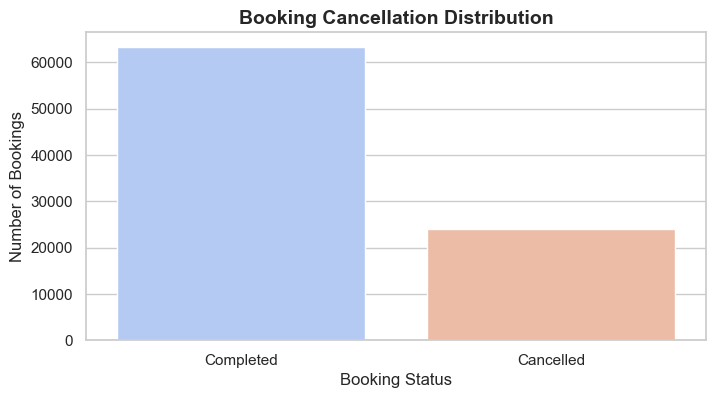

In [41]:
# Visualise cancellation distribution
plt.figure(figsize=(8,4))

sns.countplot(
    data=df,
    x="is_canceled",
    hue="is_canceled",
    palette="coolwarm",
    legend=False
)

plt.title(
    "Booking Cancellation Distribution",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Booking Status")
plt.ylabel("Number of Bookings")

plt.xticks(
    [0,1],
    ["Completed", "Cancelled"]
)

plt.show()

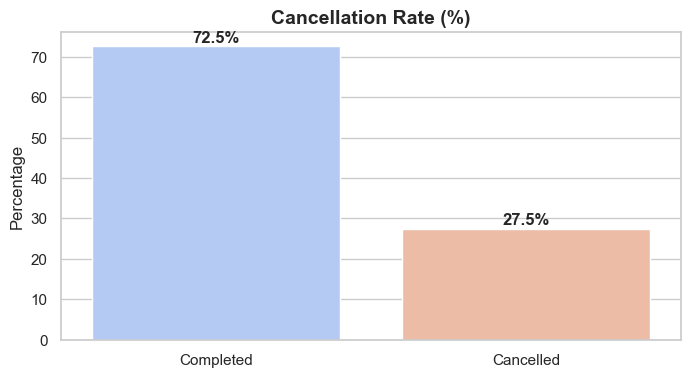

In [42]:
# Percentage visualisation
cancel_pct = (
    df["is_canceled"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

plt.figure(figsize=(8,4))

sns.barplot(
    x=["Completed", "Cancelled"],
    y=cancel_pct.values,
    palette="coolwarm"
)

plt.title(
    "Cancellation Rate (%)",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Percentage")

for i, v in enumerate(cancel_pct.values):
    plt.text(
        i,
        v + 1,
        f"{v:.1f}%",
        ha="center",
        fontweight="bold"
    )

plt.show()

<div style="color:#ab9bde;">

## <h3>Insights:</h3>


- Approximately 27.5% of all bookings were cancelled, indicating that more than one in four reservations did not result in a completed stay.

- The majority of bookings (72.5%) were successfully fulfilled, suggesting that while cancellations are not the dominant outcome, they represent a significant operational and revenue challenge.

- A cancellation rate of nearly 30% is substantial for hotel operations, as it can negatively impact occupancy forecasting, staffing decisions, inventory management, and revenue planning.

- Given the scale of cancellations (24,025 bookings), identifying high-risk reservations and customer segments presents a meaningful opportunity for improving revenue performance and operational efficiency.
</div>

### <h3 style="color: #ab9bde;">Univariate feature exploration</h3>

<div style="color:#ab9bde;">


### The goal is to understand

-  ⁠the structure of numerical features

-  ⁠the most common categories in categorical features

-  ⁠unusual values or business-relevant patterns

- ⁠which features may be useful later for cancellation prediction and revenue analysis
</div>

In [67]:
# Separate numerical and categorical columns

numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print(f"Numerical columns: {len(numerical_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")

Numerical columns: 20
Categorical columns: 12


In [68]:
numerical_cols

['is_canceled',
 'lead_time',
 'arrival_date_year',
 'arrival_date_week_number',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'booking_changes',
 'agent',
 'company',
 'days_in_waiting_list',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests']

In [69]:
categorical_cols

['hotel',
 'arrival_date_month',
 'meal',
 'country',
 'market_segment',
 'distribution_channel',
 'reserved_room_type',
 'assigned_room_type',
 'deposit_type',
 'customer_type',
 'reservation_status',
 'reservation_status_date']

In [ ]:
# Data quality summary
data_quality_summary = pd.DataFrame({
    "missing_values": df.isna().sum(),
    "missing_percentage": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique()
})

data_quality_summary.sort_values("missing_percentage", ascending=False).head(15)

,missing_values,missing_percentage,unique_values
company,82137,93.98,352
agent,12193,13.95,333
lead_time_bucket,5978,6.84,5
country,452,0.52,177
is_canceled,0,0.00,2
hotel,0,0.00,2
arrival_date_day_of_month,0,0.00,31
lead_time,0,0.00,479
arrival_date_month,0,0.00,12
arrival_date_year,0,0.00,3


In [ ]:
# Numerical columns of interest for EDA
important_numerical_cols = [
    "lead_time",
    "adr",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "booking_changes",
    "days_in_waiting_list",
    "total_of_special_requests"
]

In [73]:
# Categorical columns of interest for EDA
important_categorical_cols = [
    "hotel",
    "meal",
    "market_segment",
    "distribution_channel",
    "reserved_room_type",
    "assigned_room_type",
    "deposit_type",
    "customer_type",
    "arrival_date_month"
]

In [74]:
for col in important_categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts(normalize=True).head(10).mul(100).round(2))


hotel
hotel
City Hotel     61.13
Resort Hotel   38.87
Name: proportion, dtype: float64

meal
meal
BB          77.78
SC          10.85
HB          10.40
Undefined    0.56
FB           0.41
Name: proportion, dtype: float64

market_segment
market_segment
Online TA       59.06
Offline TA/TO   15.89
Direct          13.51
Groups           5.65
Corporate        4.82
Complementary    0.80
Aviation         0.26
Undefined        0.00
Name: proportion, dtype: float64

distribution_channel
distribution_channel
TA/TO       79.11
Direct      14.86
Corporate    5.81
GDS          0.21
Undefined    0.01
Name: proportion, dtype: float64

reserved_room_type
reserved_room_type
A   64.71
D   19.91
E    6.92
F    3.23
G    2.35
B    1.14
C    1.05
H    0.68
L    0.01
P    0.01
Name: proportion, dtype: float64

assigned_room_type
assigned_room_type
A   52.99
D   25.67
E    8.23
F    4.15
G    2.86
C    2.48
B    2.08
H    0.81
I    0.41
K    0.32
Name: proportion, dtype: float64

deposit_type
deposit_type
N

### <h2 style="color: #ab9bde;">Bivariate Features Exploration</h2>

### <h2 style="color: #ab9bde;">Categorical Features vs Cancellation</h2>


### <h3 style="color: #ab9bde;">Hotel Type vs Cancellation</h3>

Do certain hotel types experience higher cancellation risk?

In [43]:
# Cancellation rate by hotel type
hotel_cancel_rate = (
    df.groupby("hotel")["is_canceled"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .round(2)
)

hotel_cancel_rate

hotel
City Hotel     30.04
Resort Hotel   23.48
Name: is_canceled, dtype: float64

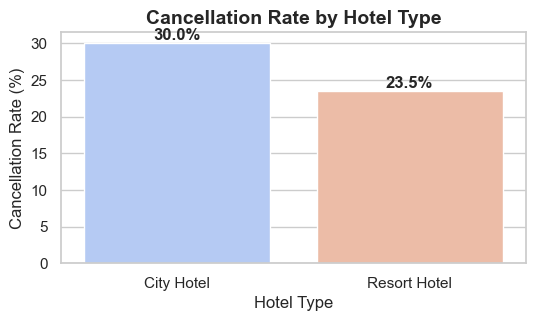

In [44]:
# Visualise cancellation rate by hotel type
plt.figure(figsize=(6,3))

sns.barplot(
    x=hotel_cancel_rate.index,
    y=hotel_cancel_rate.values,
    hue=hotel_cancel_rate.index,
    palette="coolwarm",
    legend=False
)

plt.title(
    "Cancellation Rate by Hotel Type",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Hotel Type")
plt.ylabel("Cancellation Rate (%)")

for i, value in enumerate(hotel_cancel_rate.values):
    plt.text(
        i,
        value + 0.5,
        f"{value:.1f}%",
        ha="center",
        fontweight="bold"
    )

plt.show()

In [45]:
# Hotel summary with cancellation counts and rates
hotel_summary = (
    df.groupby("hotel")
      .agg(
          total_bookings=("is_canceled", "count"),
          cancellations=("is_canceled", "sum")
      )
)

hotel_summary["cancellation_rate"] = (
    hotel_summary["cancellations"]
    / hotel_summary["total_bookings"]
    * 100
).round(2)

hotel_summary.sort_values(
    "cancellation_rate",
    ascending=False
)

,total_bookings,cancellations,cancellation_rate
hotel,,,
City Hotel,53428,16049,30.04
Resort Hotel,33968,7976,23.48


<div style="color:#ab9bde;">

## <h4>Insights:</h4>

- City Hotels face higher cancellation risk

- Revenue protection efforts should prioritize City Hotels
</div>


### <h3 style="color: #ab9bde;">Market Segment vs Cancellation</h3>

Which customer segments create the most revenue risk?

In [46]:
# Cancellation rate by market segment
market_seg = (
    df.groupby("market_segment")["is_canceled"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .round(2)
)

market_seg

market_segment
Undefined       100.00
Online TA        35.35
Groups           27.01
Aviation         19.82
Offline TA/TO    14.85
Direct           14.72
Complementary    12.54
Corporate        12.11
Name: is_canceled, dtype: float64

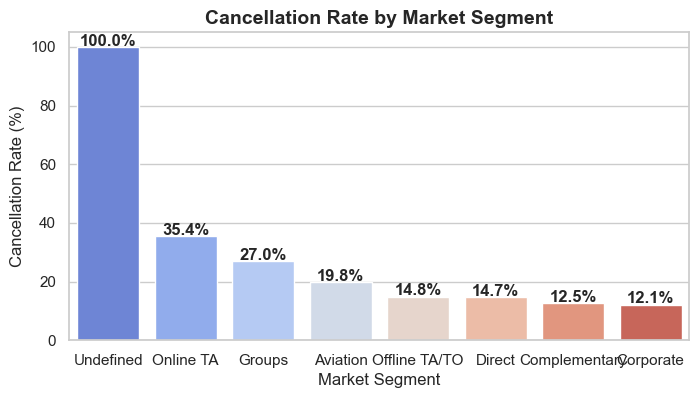

In [47]:
# Visualise cancellation rate by market segment
plt.figure(figsize=(8,4))

sns.barplot(
    x=market_seg.index,
    y=market_seg.values,
    hue=market_seg.index,
    palette="coolwarm",
    legend=False
)

plt.title(
    "Cancellation Rate by Market Segment",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Market Segment")
plt.ylabel("Cancellation Rate (%)")

for i, value in enumerate(market_seg.values):
    plt.text(
        i,
        value + 0.5,
        f"{value:.1f}%",
        ha="center",
        fontweight="bold"
    )

plt.show()

In [48]:
# Market segment summary with cancellation counts and rates
market_summary = (
    df.groupby("market_segment")
      .agg(
          total_bookings=("is_canceled", "count"),
          cancellations=("is_canceled", "sum")
      )
)

market_summary["cancellation_rate"] = (
    market_summary["cancellations"]
    / market_summary["total_bookings"]
    * 100
).round(2)

market_summary.sort_values(
    "cancellation_rate",
    ascending=False
)

,total_bookings,cancellations,cancellation_rate
market_segment,,,
Undefined,2,2,100.00
Online TA,51618,18245,35.35
Groups,4942,1335,27.01
Aviation,227,45,19.82
Offline TA/TO,13889,2063,14.85
Direct,11804,1737,14.72
Complementary,702,88,12.54
Corporate,4212,510,12.11


<div style="color:#ab9bde;">

## <h4>Insights:</h4>

- Online Travel Agencies (Online TA) are the highest-risk customer segment

- Group bookings show elevated cancellation risk

- Direct and Corporate bookings are more reliable

- Online TA vs Direct Booking Gap is Significant

- Undefined Segment Should Not Influence Decisions
</div>

### <h3 style="color: #ab9bde;">Deposit type vs Cancellation</h3>

In [49]:
# Cancellation rate by deposit type
deposit_type_cancel = (
    df.groupby("deposit_type")["is_canceled"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .round(2)
)

deposit_type_cancel

deposit_type
Non Refund   94.70
No Deposit   26.68
Refundable   24.30
Name: is_canceled, dtype: float64

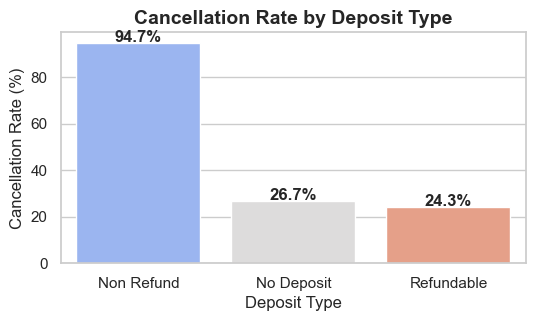

In [50]:
# Visualise cancellation rate by deposit type
plt.figure(figsize=(6,3))

sns.barplot(
    x=deposit_type_cancel.index,
    y=deposit_type_cancel.values,
    hue=deposit_type_cancel.index,
    palette="coolwarm",
    legend=False
)

plt.title(
    "Cancellation Rate by Deposit Type",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Deposit Type")
plt.ylabel("Cancellation Rate (%)")

for i, value in enumerate(deposit_type_cancel.values):
    plt.text(
        i,
        value + 0.5,
        f"{value:.1f}%",
        ha="center",
        fontweight="bold"
    )

plt.show()

In [51]:
# Deposit type summary with cancellation counts and rates
deposit_type_summary = (
    df.groupby("deposit_type")
      .agg(
          total_bookings=("is_canceled", "count"),
          cancellations=("is_canceled", "sum")
      )
)

deposit_type_summary["cancellation_rate"] = (
    deposit_type_summary["cancellations"]
    / deposit_type_summary["total_bookings"]
    * 100
).round(2)

deposit_type_summary.sort_values(
    "cancellation_rate",
    ascending=False
)

,total_bookings,cancellations,cancellation_rate
deposit_type,,,
Non Refund,1038,983,94.70
No Deposit,86251,23016,26.68
Refundable,107,26,24.30


<div style="color:#ab9bde;">

## <h4>Insights:</h4>

- Non-Refund Deposits Have Extremely High Cancellation Rates

- Deposit Type is One of the Strongest Predictors of Cancellation

- Most Business Risk Comes From "No Deposit" Bookings

- Deposit Policies Appear Closely Linked to Cancellation Behavior

</div>

### <h3 style="color: #ab9bde;">Customer Type vs Cancellation</h3>

In [58]:
# Cancellation rate by customer type
customer_type_cancel = (
    df.groupby("customer_type")["is_canceled"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .round(2)
)

customer_type_cancel

customer_type
Transient         30.11
Contract          16.31
Transient-Party   15.24
Group              9.93
Name: is_canceled, dtype: float64

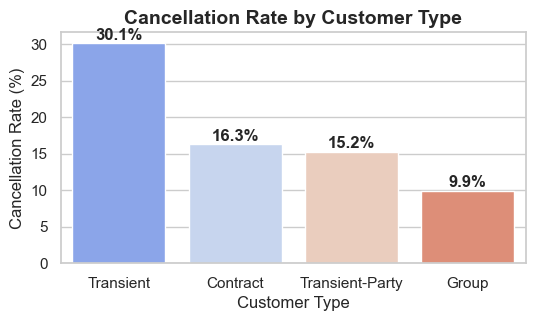

In [59]:
# Visualise cancellation rate by customer type
plt.figure(figsize=(6,3))

sns.barplot(
    x=customer_type_cancel.index,
    y=customer_type_cancel.values,
    hue=customer_type_cancel.index,
    palette="coolwarm",
    legend=False
)

plt.title(
    "Cancellation Rate by Customer Type",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Customer Type")
plt.ylabel("Cancellation Rate (%)")

for i, value in enumerate(customer_type_cancel.values):
    plt.text(
        i,
        value + 0.5,
        f"{value:.1f}%",
        ha="center",
        fontweight="bold"
    )

plt.show()

In [60]:
# Customer type summary with cancellation counts and rates
customer_type_summary = (
    df.groupby("customer_type")
      .agg(
          total_bookings=("is_canceled", "count"),
          cancellations=("is_canceled", "sum")
      )
)

customer_type_summary["cancellation_rate"] = (
    customer_type_summary["cancellations"]
    / customer_type_summary["total_bookings"]
    * 100
).round(2)

customer_type_summary.sort_values(
    "cancellation_rate",
    ascending=False
)

,total_bookings,cancellations,cancellation_rate
customer_type,,,
Transient,71986,21672,30.11
Contract,3139,512,16.31
Transient-Party,11727,1787,15.24
Group,544,54,9.93


<div style="color:#ab9bde;">

## <h4>Insights:</h4>

- Transient customers are the highest cancellation risk

- Group bookings are the most reliable

- Contract customers show strong commitment


</div>

### <h2 style="color: #ab9bde;">Numerical Features vs Cancellation</h2>

In [122]:
df.groupby("is_canceled")[numerical_features].mean().T.round(2)

is_canceled,0,1
lead_time,70.10,105.72
adr,102.00,117.77
previous_cancellations,0.02,0.06
booking_changes,0.31,0.16
days_in_waiting_list,0.72,0.82
total_of_special_requests,0.76,0.54
stays_in_weekend_nights,0.97,1.11
stays_in_week_nights,2.52,2.90
adults,1.84,1.96
children,0.12,0.19


### <h3 style="color: #ab9bde;">Numerical Feature Correlation Analysis</h3>

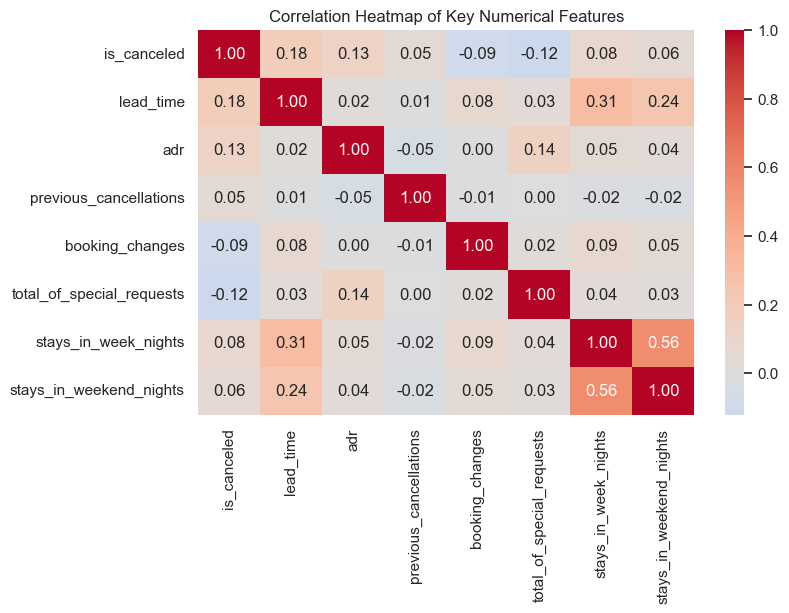

In [125]:
selected_corr_cols = [
    "is_canceled",
    "lead_time",
    "adr",
    "previous_cancellations",
    "booking_changes",
    "total_of_special_requests",
    "stays_in_week_nights",
    "stays_in_weekend_nights"
]

plt.figure(figsize=(8, 5))

sns.heatmap(
    df[selected_corr_cols].corr(),
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Correlation Heatmap of Key Numerical Features")
plt.show()

In [ ]:
target_corr = (
    corr_matrix["is_canceled"]
    .sort_values(ascending=False)
)

target_corr

is_canceled                       1.00
lead_time                         0.18
adr                               0.13
arrival_date_year                 0.09
stays_in_week_nights              0.08
adults                            0.08
children                          0.07
stays_in_weekend_nights           0.06
previous_cancellations            0.05
company                           0.01
arrival_date_day_of_month         0.01
days_in_waiting_list              0.00
arrival_date_week_number          0.00
babies                           -0.02
agent                            -0.04
previous_bookings_not_canceled   -0.05
is_repeated_guest                -0.09
booking_changes                  -0.09
total_of_special_requests        -0.12
required_car_parking_spaces      -0.18
Name: is_canceled, dtype: float64

<div style="color:#ab9bde;">

## <h4>Insights:</h4>

- Cancelled bookings have higher lead times.

- Cancelled bookings have higher ADR.

- Non-cancelled bookings make more booking changes.
</div>

### <h3 style="color: #ab9bde;">Lead Time vs Cancellation</h3>

In [114]:
# Create lead time buckets
lead_time_bins = [
    0,
    30,
    90,
    180,
    365,
    800
]

lead_time_labels = [
    "0-30 Days",
    "31-90 Days",
    "91-180 Days",
    "181-365 Days",
    "365+ Days"
]

df["lead_time_bucket"] = pd.cut(
    df["lead_time"],
    bins=lead_time_bins,
    labels=lead_time_labels,
    include_lowest=True
)

In [115]:
df["lead_time_bucket"].isna().sum()

np.int64(0)

In [ ]:
# Lead time summary with cancellation counts and rates
lead_time_summary = (
    df.groupby("lead_time_bucket")
      .agg(
          total_bookings=("is_canceled","count"),
          cancellations=("is_canceled","sum")
      )
)

lead_time_summary["cancellation_rate"] = (
    lead_time_summary["cancellations"]
    / lead_time_summary["total_bookings"]
    * 100
).round(2)

lead_time_summary

,total_bookings,cancellations,cancellation_rate
lead_time_bucket,,,
0-30 Days,28666,5335,18.61
31-90 Days,22744,7280,32.01
91-180 Days,18243,6382,34.98
181-365 Days,11200,4444,39.68
365+ Days,565,231,40.88


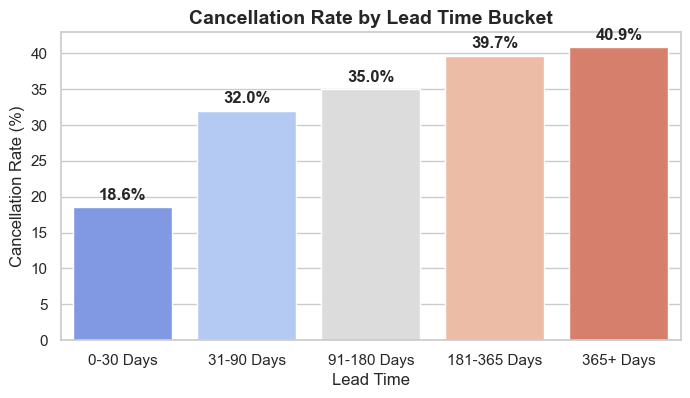

In [ ]:
# Visualise summary of cancellation rate by lead time bucket
plt.figure(figsize=(8,4))

sns.barplot(
    data=lead_time_summary.reset_index(),
    x="lead_time_bucket",
    y="cancellation_rate",
    palette="coolwarm"
)

plt.title(
    "Cancellation Rate by Lead Time Bucket",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Lead Time")
plt.ylabel("Cancellation Rate (%)")

for i, value in enumerate(
    lead_time_summary["cancellation_rate"]
):
    plt.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center",
        fontweight="bold"
    )

plt.show()

<div style="color:#ab9bde;">

## <h4>Insights:</h4>

- Cancellation rates increase steadily as lead time increases.

- Bookings made within 30 days of arrival have the lowest cancellation rate (18.6%), while bookings made more than one year in advance exceed 40% cancellation.

- This suggests that customers who book far in advance are significantly more likely to change their plans before arrival.

</div>

### <h3 style="color: #ab9bde;">Average Daily Rate vs Cancellation</h3>

Do expensive bookings cancel more often?

In [79]:
# ADR buckets

adr_bins = [0, 50, 100, 150, 200, 300, float("inf")]

adr_labels = [
    "0-50",
    "51-100",
    "101-150",
    "151-200",
    "201-300",
    "300+"
]

df["adr_bucket"] = pd.cut(
    df["adr"],
    bins=adr_bins,
    labels=adr_labels,
    include_lowest=True
)

df["adr_bucket"].value_counts().sort_index()

adr_bucket
0-50        9857
51-100     35793
101-150    26632
151-200    10395
201-300     4457
300+         261
Name: count, dtype: int64

In [80]:
# Cancellation rate by ADR bucket
adr_summary = (
    df.groupby("adr_bucket")
      .agg(
          total_bookings=("is_canceled", "count"),
          cancellations=("is_canceled", "sum")
      )
)

adr_summary["cancellation_rate"] = (
    adr_summary["cancellations"]
    / adr_summary["total_bookings"]
    * 100
).round(2)

adr_summary

,total_bookings,cancellations,cancellation_rate
adr_bucket,,,
0-50,9857,1471,14.92
51-100,35793,8758,24.47
101-150,26632,8493,31.89
151-200,10395,3530,33.96
201-300,4457,1687,37.85
300+,261,86,32.95


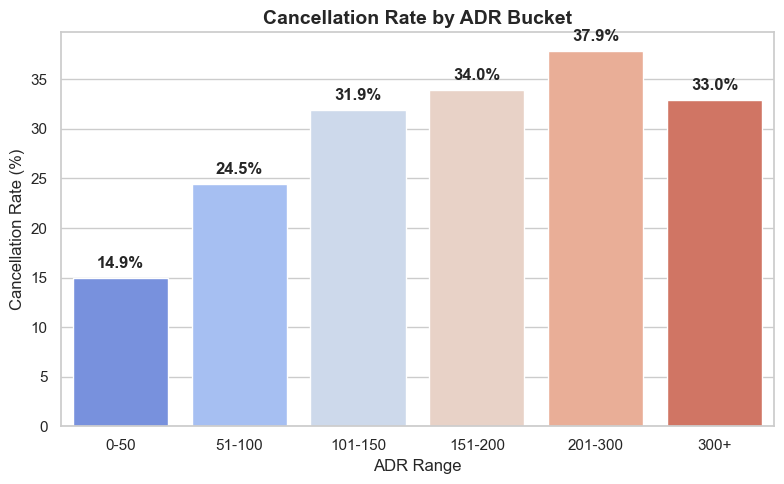

In [81]:
# Visualise cancellation rate by ADR bucket
plt.figure(figsize=(8,5))

sns.barplot(
    data=adr_summary.reset_index(),
    x="adr_bucket",
    y="cancellation_rate",
    palette="coolwarm"
)

plt.title(
    "Cancellation Rate by ADR Bucket",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("ADR Range")
plt.ylabel("Cancellation Rate (%)")

for i, value in enumerate(adr_summary["cancellation_rate"]):
    plt.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

<div style="color:#ab9bde;">

## <h4>Insights:</h4>

- Cancellation rate rises as room price increases

- Highest risk segment = ADR 201–300

- Budget bookings are more reliable & 300+ bucket is not reliable

</div>

### <h3 style="color: #ab9bde;">Previous cancellations vs Cancellation</h3>

In [82]:
# Cancellation rate by previous cancellations

previous_cancel_rate = (
    df.groupby("previous_cancellations")["is_canceled"]
    .mean()
    .reset_index()
)

previous_cancel_rate["cancellation_rate"] = previous_cancel_rate["is_canceled"] * 100

previous_cancel_rate.head(10)

,previous_cancellations,is_canceled,cancellation_rate
0,0,0.27,26.70
1,1,0.76,76.12
2,2,0.30,30.36
3,3,0.26,26.23
4,4,0.20,20.00
5,5,0.11,10.53
6,6,0.12,11.76
7,11,0.07,7.41
8,13,0.75,75.00
9,14,1.00,100.00


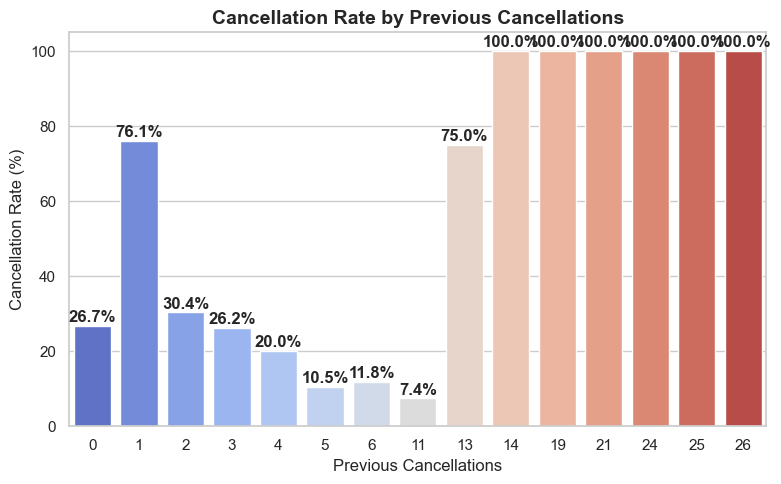

In [124]:
# Visualise cancellation by previous cancellations

plt.figure(figsize=(8,5))

sns.barplot(
    data=previous_cancel_rate,
    x="previous_cancellations",
    y="cancellation_rate",
    palette="coolwarm"
)

plt.title(
    "Cancellation Rate by Previous Cancellations",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Previous Cancellations")
plt.ylabel("Cancellation Rate (%)")

for i, value in enumerate(previous_cancel_rate["cancellation_rate"]):
    plt.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [85]:
previous_cancel_counts = (
    df["previous_cancellations"]
    .value_counts()
    .sort_index()
    .reset_index()
)

previous_cancel_counts.columns = ["previous_cancellations", "booking_count"]

previous_cancel_counts

,previous_cancellations,booking_count
0,0,85711
1,1,1407
2,2,112
3,3,61
4,4,30
5,5,19
6,6,17
7,11,27
8,13,4
9,14,1


<div style="color:#ab9bde;">

## <h4>Insights:</h4>
- Bookings with ⁠ 0 ⁠ previous cancellations make up the majority of the data, with 85,711 bookings, and have a cancellation rate of 26.7%.

- Bookings with ⁠ 1 ⁠ previous cancellation have 1,407 bookings and show a much higher cancellation rate of 76.1%. This is the strongest reliable signal in this feature.

- After ⁠ 1 ⁠ previous cancellation, the number of bookings becomes much smaller:

- Some higher previous-cancellation values show very high cancellation rates, including 75% or 100%, but these groups have very few bookings. For example, values such as ⁠ 14 ⁠, ⁠ 19 ⁠, ⁠ 21 ⁠, and ⁠ 26 ⁠ are based on only 1 booking, so they should not be treated as reliable patterns.

- Overall, the key insight is that customers with exactly 1 previous cancellation show a clearly higher cancellation rate compared with customers who had no previous cancellations.

</div>

### <h3 style="color: #ab9bde;">Booking changes vs cancellation</h3>

In [86]:
# Cancellation rate by number of booking changes

booking_changes_rate = (
    df.groupby("booking_changes")["is_canceled"]
    .mean()
    .reset_index()
)

booking_changes_rate["cancellation_rate"] = booking_changes_rate["is_canceled"] * 100

booking_changes_rate.head(10)

,booking_changes,is_canceled,cancellation_rate
0,0,0.30,30.17
1,1,0.14,13.86
2,2,0.20,20.07
3,3,0.15,14.97
4,4,0.18,17.70
5,5,0.17,17.24
6,6,0.29,28.81
7,7,0.10,9.68
8,8,0.24,23.53
9,9,0.12,12.50


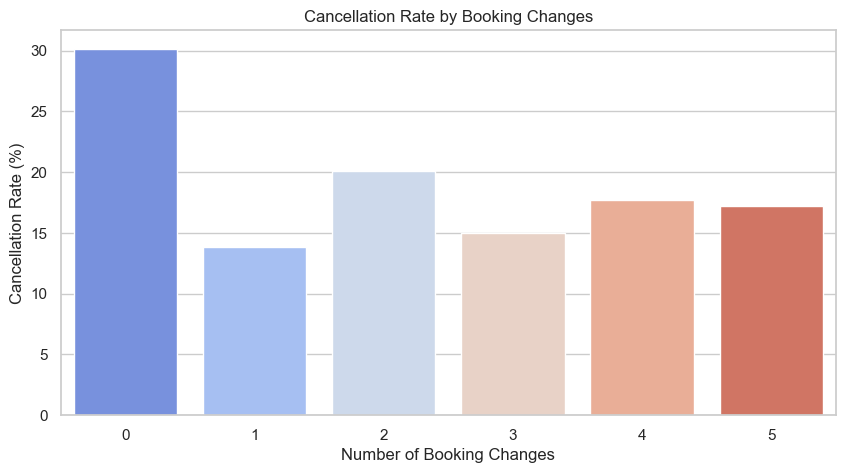

In [92]:
# Visualise cancellation by booking changes
booking_changes_rate_filtered = booking_changes_rate[
    booking_changes_rate["booking_changes"] <= 5
]

plt.figure(figsize=(10, 5))

sns.barplot(
    data=booking_changes_rate_filtered,
    x="booking_changes",
    y="cancellation_rate",
    palette="coolwarm"
)

plt.title("Cancellation Rate by Booking Changes")
plt.xlabel("Number of Booking Changes")
plt.ylabel("Cancellation Rate (%)")
plt.show()

In [ ]:
# Summary
booking_changes_counts = (
    df["booking_changes"]
    .value_counts()
    .sort_index()
    .reset_index()
)

booking_changes_counts.columns = ["booking_changes", "booking_count"]

booking_changes_counts

,booking_changes,booking_count
0,0,71494
1,1,10902
2,2,3508
3,3,875
4,4,356
5,5,116
6,6,59
7,7,31
8,8,17
9,9,8


<div style="color:#ab9bde;">

## <h4>Insights:</h4>
- Bookings with ⁠ 0 ⁠ changes make up the majority of the dataset, with 71,494 bookings, and have a cancellation rate of 30.17%.

- Bookings with ⁠ 1 ⁠ change have 10,902 bookings and a much lower cancellation rate of 13.86%. Bookings with ⁠ 2 ⁠ changes also show a lower cancellation rate of 20.07% compared with bookings with no changes.

- For the most reliable groups, the pattern suggests that bookings with no changes are more likely to be cancelled than bookings where the guest has made at least one modification.

- The groups with higher numbers of booking changes become much smaller. For example, there are only 59 bookings with ⁠ 6 ⁠ changes, 31 bookings with ⁠ 7 ⁠ changes, and fewer than 20 bookings for many higher values. Because of these small sample sizes, cancellation rates for higher booking-change values should be interpreted carefully.

- Overall, the clearest insight is that bookings with 0 booking changes have a noticeably higher cancellation rate than bookings with ⁠ 1–3 ⁠ changes. This may indicate that some level of guest interaction or modification is associated with a lower cancellation tendency.

</div>

### <h3 style="color: #ab9bde;">Special requests vs cancellation</h3>

In [90]:
# Cancellation rate by total special requests

special_requests_rate = (
    df.groupby("total_of_special_requests")["is_canceled"]
    .mean()
    .reset_index()
)

special_requests_rate["cancellation_rate"] = special_requests_rate["is_canceled"] * 100

special_requests_rate

,total_of_special_requests,is_canceled,cancellation_rate
0,0,0.33,33.20
1,1,0.22,22.41
2,2,0.21,21.29
3,3,0.17,17.13
4,4,0.11,10.62
5,5,0.06,5.56


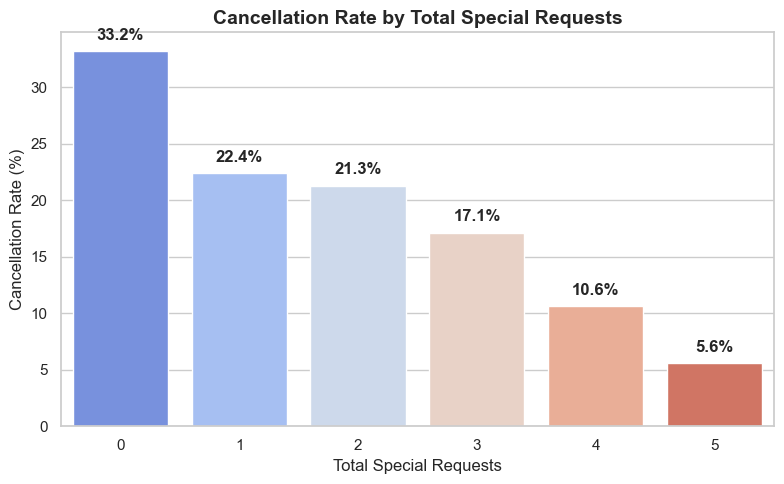

In [91]:
# Visualise cancellation by special requests

plt.figure(figsize=(8,5))

sns.barplot(
    data=special_requests_rate,
    x="total_of_special_requests",
    y="cancellation_rate",
    palette="coolwarm"
)

plt.title(
    "Cancellation Rate by Total Special Requests",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Total Special Requests")
plt.ylabel("Cancellation Rate (%)")

for i, value in enumerate(special_requests_rate["cancellation_rate"]):
    plt.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

<div style="color:#ab9bde;">

## <h4>Bivariate Analysis Summary:</h4>
- The bivariate analysis shows that cancellation behaviour is influenced by both categorical and numerical booking features.

- The strongest categorical signals appear to come from ⁠ deposit_type ⁠, ⁠ market_segment ⁠, ⁠ customer_type ⁠, and ⁠ hotel ⁠.

- Among numerical features, ⁠ lead_time ⁠, ⁠ adr ⁠, ⁠ previous_cancellations ⁠, ⁠ booking_changes ⁠, and ⁠ total_of_special_requests ⁠ show meaningful differences between cancelled and non-cancelled bookings.

- Overall, bookings with longer lead times, higher ADR, previous cancellation history, no booking changes, and fewer special requests appear to carry higher cancellation risk.
</div>

### <h2 style="color: #ab9bde;">Temporal Patterns</h2>



This section explores how cancellation behaviour changes across time-related booking features.

The goal is to identify whether cancellations are more common during specific months, seasons, or arrival periods.

### <h3 style="color: #ab9bde;">Monthly cancellation rate</h3>

In [93]:
monthly_cancel_rate = (
    df.groupby("arrival_date_month")["is_canceled"]
    .mean()
    .reset_index()
)

monthly_cancel_rate["cancellation_rate"] = monthly_cancel_rate["is_canceled"] * 100

monthly_cancel_rate

,arrival_date_month,is_canceled,cancellation_rate
0,April,0.30,30.46
1,August,0.32,32.18
2,December,0.27,26.86
3,February,0.23,23.20
4,January,0.22,22.12
5,July,0.32,31.80
6,June,0.30,30.32
7,March,0.24,24.36
8,May,0.29,29.23
9,November,0.21,21.10


In [94]:
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

monthly_cancel_rate["arrival_date_month"] = pd.Categorical(
    monthly_cancel_rate["arrival_date_month"],
    categories=month_order,
    ordered=True
)

monthly_cancel_rate = monthly_cancel_rate.sort_values("arrival_date_month")

monthly_cancel_rate

,arrival_date_month,is_canceled,cancellation_rate
4,January,0.22,22.12
3,February,0.23,23.20
7,March,0.24,24.36
0,April,0.30,30.46
8,May,0.29,29.23
6,June,0.30,30.32
5,July,0.32,31.80
1,August,0.32,32.18
11,September,0.25,24.54
10,October,0.24,23.68


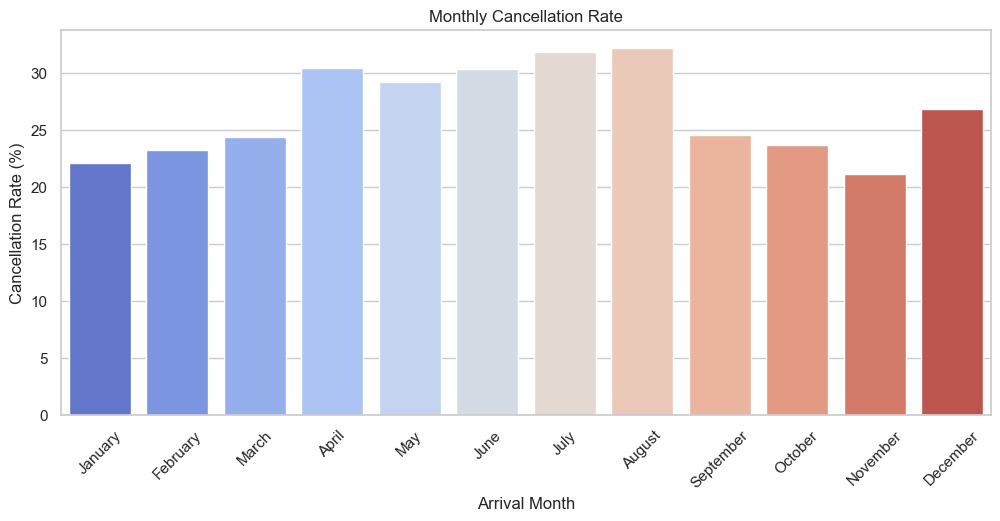

In [95]:
plt.figure(figsize=(12, 5))

sns.barplot(
    data=monthly_cancel_rate,
    x="arrival_date_month",
    y="cancellation_rate",
    palette="coolwarm"
)

plt.title("Monthly Cancellation Rate")
plt.xlabel("Arrival Month")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=45)
plt.show()

<div style="color:#ab9bde;">
<h4>Insights:</h4>

- Cancellations are higher during several busier travel months, especially around summer and late spring.

- However, this table only shows cancellation rate by month. To understand whether this is also linked to booking volume, the next step should compare monthly booking counts alongside cancellation rates.
</div>

### <h3 style="color: #ab9bde;">Monthly booking volume</h3>

In [96]:
# Monthly booking volume

monthly_booking_volume = (
    df["arrival_date_month"]
    .value_counts()
    .reset_index()
)

monthly_booking_volume.columns = ["arrival_date_month", "booking_count"]

monthly_booking_volume

,arrival_date_month,booking_count
0,August,11257
1,July,10057
2,May,8355
3,April,7908
4,June,7765
5,March,7513
6,October,6934
7,September,6690
8,February,6098
9,December,5131


In [97]:
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

monthly_booking_volume["arrival_date_month"] = pd.Categorical(
    monthly_booking_volume["arrival_date_month"],
    categories=month_order,
    ordered=True
)

monthly_booking_volume = monthly_booking_volume.sort_values("arrival_date_month")

monthly_booking_volume

,arrival_date_month,booking_count
11,January,4693
8,February,6098
5,March,7513
3,April,7908
2,May,8355
4,June,7765
1,July,10057
0,August,11257
7,September,6690
6,October,6934


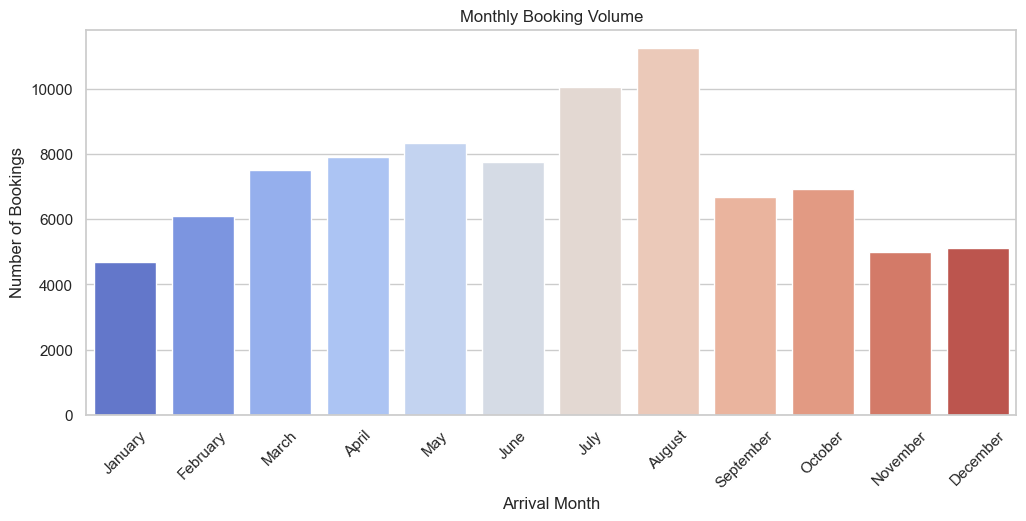

In [98]:
plt.figure(figsize=(12, 5))

sns.barplot(
    data=monthly_booking_volume,
    x="arrival_date_month",
    y="booking_count",
    palette="coolwarm"
)

plt.title("Monthly Booking Volume")
plt.xlabel("Arrival Month")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.show()

In [99]:
monthly_summary = monthly_cancel_rate.merge(
    monthly_booking_volume,
    on="arrival_date_month",
    how="left"
)

monthly_summary

,arrival_date_month,is_canceled,cancellation_rate,booking_count
0,January,0.22,22.12,4693
1,February,0.23,23.20,6098
2,March,0.24,24.36,7513
3,April,0.30,30.46,7908
4,May,0.29,29.23,8355
5,June,0.30,30.32,7765
6,July,0.32,31.80,10057
7,August,0.32,32.18,11257
8,September,0.25,24.54,6690
9,October,0.24,23.68,6934


<div style="color:#ab9bde;">
<h4>Insights:</h4>

- This shows that booking demand is strongest around late spring and summer, especially in July and August.

- When compared with the monthly cancellation rate, this becomes more important because July and August are both high-volume and high-cancellation months. This means cancellations during these months may create a larger operational and revenue impact for hotels.
</div>

### <h3 style="color: #ab9bde;">Monthly cancellation rate by hotel type</h3>

In [100]:
hotel_monthly_cancel_rate = (
    df.groupby(["arrival_date_month", "hotel"])["is_canceled"]
    .mean()
    .reset_index()
)

hotel_monthly_cancel_rate["cancellation_rate"] = hotel_monthly_cancel_rate["is_canceled"] * 100

hotel_monthly_cancel_rate["arrival_date_month"] = pd.Categorical(
    hotel_monthly_cancel_rate["arrival_date_month"],
    categories=month_order,
    ordered=True
)

hotel_monthly_cancel_rate = hotel_monthly_cancel_rate.sort_values("arrival_date_month")

hotel_monthly_cancel_rate.head()

,arrival_date_month,hotel,is_canceled,cancellation_rate
8,January,City Hotel,0.28,27.99
9,January,Resort Hotel,0.14,13.96
6,February,City Hotel,0.27,27.05
7,February,Resort Hotel,0.18,17.65
15,March,Resort Hotel,0.18,17.50


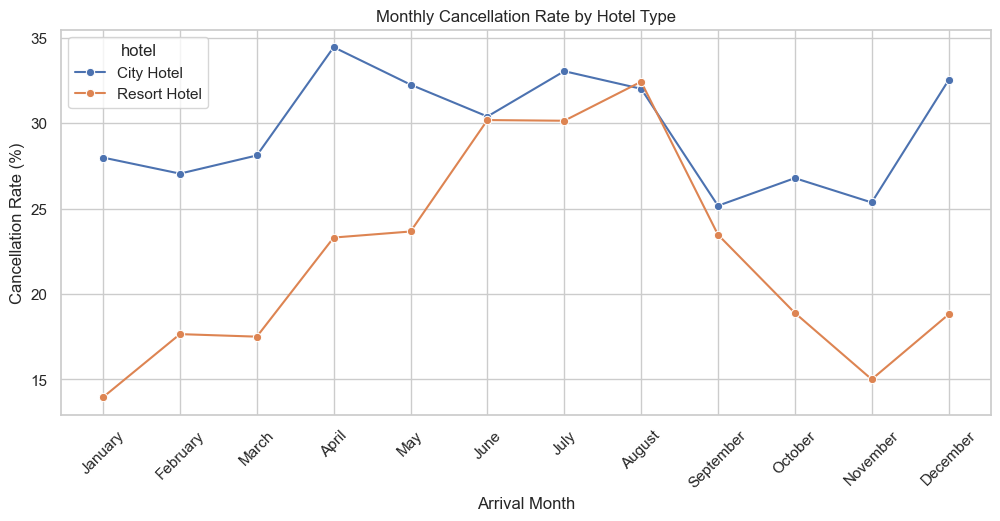

In [101]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=hotel_monthly_cancel_rate,
    x="arrival_date_month",
    y="cancellation_rate",
    hue="hotel",
    marker="o"
)

plt.title("Monthly Cancellation Rate by Hotel Type")
plt.xlabel("Arrival Month")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=45)
plt.show()

In [102]:
hotel_monthly_volume = (
    df.groupby(["arrival_date_month", "hotel"])
    .size()
    .reset_index(name="booking_count")
)

hotel_monthly_volume["arrival_date_month"] = pd.Categorical(
    hotel_monthly_volume["arrival_date_month"],
    categories=month_order,
    ordered=True
)

hotel_monthly_volume = hotel_monthly_volume.sort_values(
    ["arrival_date_month", "hotel"]
)

hotel_monthly_volume

,arrival_date_month,hotel,booking_count
8,January,City Hotel,2730
9,January,Resort Hotel,1963
6,February,City Hotel,3605
7,February,Resort Hotel,2493
14,March,City Hotel,4856
15,March,Resort Hotel,2657
0,April,City Hotel,5080
1,April,Resort Hotel,2828
16,May,City Hotel,5413
17,May,Resort Hotel,2942


<div style="color:#ab9bde;">
<h4>Insights:</h4>

- City Hotel generally shows a higher cancellation rate than Resort Hotel across most months. The City Hotel cancellation rate stays relatively high throughout the year, mostly between the mid-20% and mid-30% range.

- Resort Hotel shows a stronger seasonal pattern. Its cancellation rate is much lower in the winter months, especially around January, October, and November, but increases sharply during the summer period.

- In August, Resort Hotel cancellation rate becomes very close to City Hotel, showing that summer is an important cancellation-risk period for both hotel types.

- Overall, City Hotel has more consistent cancellation pressure across the year, while Resort Hotel shows stronger seasonality, with cancellation risk increasing during peak summer months.

</div>

### <h1 style="color: #ab9bde;">Imbalance Documentation</h1>

### <h2 style="color: #ab9bde;">Overall target imbalance</h2>

In [103]:
# Overall target imbalance

target_distribution = (
    df["is_canceled"]
    .value_counts()
    .reset_index()
)

target_distribution.columns = ["is_canceled", "booking_count"]

target_distribution["percentage"] = (
    target_distribution["booking_count"] / len(df) * 100
).round(2)

target_distribution

,is_canceled,booking_count,percentage
0,0,63371,72.51
1,1,24025,27.49


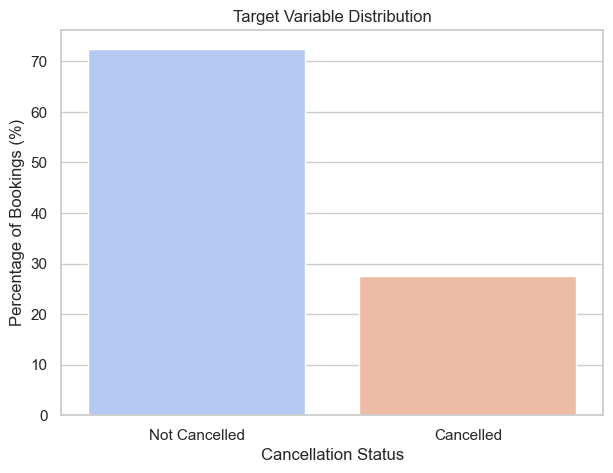

In [104]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=target_distribution,
    x="is_canceled",
    y="percentage",
    palette="coolwarm"
)

plt.title("Target Variable Distribution")
plt.xlabel("Cancellation Status")
plt.ylabel("Percentage of Bookings (%)")
plt.xticks([0, 1], ["Not Cancelled", "Cancelled"])
plt.show()

<div style="color:#ab9bde;">
<h4>Insights:</h4>

- The target variable ⁠ is_canceled ⁠ is moderately imbalanced.

- The dataset contains 63,371 non-cancelled bookings, representing 72.51% of all bookings, and 24,025 cancelled bookings, representing 27.49%.

- This means the majority class is non-cancelled bookings, but the cancelled class is still large enough to provide meaningful patterns for analysis and future modeling.

- For modeling, this imbalance should still be considered. Accuracy alone may be misleading, because a model could perform well by favoring the majority class. 

- Future model evaluation should include precision, recall, F1-score, and confusion matrix.

</div>

### <h2 style="color: #ab9bde;">Feature-level imbalance</h2>

In [105]:
important_categorical_features = [
    "hotel",
    "market_segment",
    "deposit_type",
    "customer_type",
    "arrival_date_month"
]

In [106]:
for col in important_categorical_features:
    print(f"\nFeature: {col}")
    feature_balance = (
        df[col]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
        .reset_index()
    )
    feature_balance.columns = [col, "percentage"]
    display(feature_balance)


Feature: hotel


,hotel,percentage
0,City Hotel,61.13
1,Resort Hotel,38.87



Feature: market_segment


,market_segment,percentage
0,Online TA,59.06
1,Offline TA/TO,15.89
2,Direct,13.51
3,Groups,5.65
4,Corporate,4.82
5,Complementary,0.80
6,Aviation,0.26
7,Undefined,0.00



Feature: deposit_type


,deposit_type,percentage
0,No Deposit,98.69
1,Non Refund,1.19
2,Refundable,0.12



Feature: customer_type


,customer_type,percentage
0,Transient,82.37
1,Transient-Party,13.42
2,Contract,3.59
3,Group,0.62



Feature: arrival_date_month


,arrival_date_month,percentage
0,August,12.88
1,July,11.51
2,May,9.56
3,April,9.05
4,June,8.88
5,March,8.60
6,October,7.93
7,September,7.65
8,February,6.98
9,December,5.87


<div style="color:#ab9bde;">
<h4>Insights:</h4>

- The ⁠ hotel ⁠ feature is moderately imbalanced, with City Hotel representing 61.13% of bookings and Resort Hotel representing 38.87%.


- The ⁠ market_segment ⁠ feature is more strongly imbalanced. Online TA accounts for 59.06% of all bookings, while smaller segments such as Complementary, Aviation, and Undefined represent less than 1% each. This means cancellation patterns in very small market segments should be interpreted carefully.


- The ⁠ deposit_type ⁠ feature is heavily imbalanced. No Deposit represents 98.69% of bookings, while Non Refund represents 1.19% and Refundable only 0.12%. Because the minority deposit categories are very small, their cancellation rates may be highly informative but should be handled carefully during modeling.


- The ⁠ customer_type ⁠ feature is also imbalanced. Transient customers represent 82.37% of bookings, while Group customers represent only 0.62%. This suggests that the dataset is mainly driven by individual/transient booking behavior.
 

- The ⁠ arrival_date_month ⁠ feature is more evenly distributed compared with the other categorical features, although August and July have the highest shares of bookings at 12.88% and 11.51% respectively.

- Overall, feature-level imbalance is important because small categories can produce very high or very low cancellation rates that may not always be reliable. In future modeling, rare categories may need to be grouped, encoded carefully, or reviewed separately.


</div>

### <h1 style="color: #ab9bde;">Revenue impact framing</h1>

In [107]:
# Create total nights
df["total_nights"] = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]

In [116]:
# Create estimated booking value
df[df["adr"] < 0][["adr", "total_nights", "estimated_booking_value"]]

,adr,total_nights,estimated_booking_value
11591,-6.38,10,-63.80


In [117]:
revenue_df = df[
    (df["adr"] > 0) & 
    (df["total_nights"] > 0)
].copy()

In [119]:
# Check summary
df[["adr", "total_nights", "estimated_booking_value"]].describe().T

,count,mean,std,min,25%,50%,75%,max
adr,87396.00,106.34,55.01,-6.38,72.00,98.10,134.00,5400.00
total_nights,87396.00,3.63,2.76,0.00,2.00,3.00,5.00,69.00
estimated_booking_value,87396.00,394.31,369.45,-63.80,152.47,299.00,503.20,7590.00


In [110]:
# Compare cancelled vs not cancelled
revenue_by_cancellation = (
    df.groupby("is_canceled")["estimated_booking_value"]
    .agg(["count", "mean", "median", "sum"])
    .reset_index()
)

revenue_by_cancellation

,is_canceled,count,mean,median,sum
0,0,63371,362.58,274.53,22976896.33
1,1,24025,478.00,362.95,11484042.98


In [111]:
# Add label
revenue_by_cancellation["status"] = revenue_by_cancellation["is_canceled"].map({
    0: "Not Cancelled",
    1: "Cancelled"
})

revenue_by_cancellation

,is_canceled,count,mean,median,sum,status
0,0,63371,362.58,274.53,22976896.33,Not Cancelled
1,1,24025,478.00,362.95,11484042.98,Cancelled


In [121]:
target_distribution = (
    df["is_canceled"]
    .value_counts()
    .reset_index()
)

target_distribution.columns = ["is_canceled", "booking_count"]

target_distribution["percentage"] = (
    target_distribution["booking_count"] / len(df) * 100
).round(2)

target_distribution

,is_canceled,booking_count,percentage
0,0,63371,72.51
1,1,24025,27.49


<div style="color:#ab9bde;">
<h4>Insights:</h4>

- Using ⁠ adr × total_nights ⁠ as a simple estimated booking value, cancelled bookings show a higher average booking value than non-cancelled bookings.

- The average estimated value of a cancelled booking is 478.00, compared with 362.58 for a non-cancelled booking.


- In total, cancelled bookings represent approximately 11.48 million in estimated booking value.


- This does not mean the hotel lost the full amount, because some cancelled rooms may have been resold. However, it shows that cancellations are attached to a large amount of potential revenue exposure.
 

- This supports the business case for a cancellation-risk assistant: identifying high-risk bookings early could help hotel managers protect revenue, improve follow-up actions, and reduce avoidable losse.


</div>

### <h3 style="color: #ab9bde;">Save EDA performed Dataset</h3>

In [126]:
df.to_csv(
    "../data/hotel_bookings_eda.csv",
    index=False
)

print("EDA enriched dataset saved successfully.")

EDA enriched dataset saved successfully.
